# Genetik Algoritmalar ile Özellik Seçimi (Breast Cancer)

Bu notebook, **Genetik Algoritmalar (GA)** kavramlarını **Breast Cancer Wisconsin** veri seti üzerinde **özellik seçimi** problemine uygulamaktadır.

Orijinal tutorial'da GA'lar Rastrigin fonksiyonu üzerinde optimize edilirken, bu uyarlamada gerçek bir tıbbi veri seti kullanılarak en iyi özellik alt kümesi aranacaktır.

**Veri Seti:** [Breast Cancer Wisconsin - Kaggle](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data)

**Uygulanan GA Bileşenleri:**
- Kromozom: İkili vektör (1=özellik seçili, 0=seçilmemiş)
- Uygunluk: Seçili özelliklerle elde edilen cross-validated doğruluk
- Seçim: Turnuva seçimi
- Çaprazlama: Tek noktalı çaprazlama
- Mutasyon: Bit-flip mutasyonu
- Elitizm: En iyi bireyi koruma

In [1]:
!pip install kaggle scikit-learn pandas numpy matplotlib seaborn -q

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import random
import time
from copy import deepcopy

np.random.seed(42)
random.seed(42)
print("Tüm kütüphaneler başarıyla yüklendi!")

Tüm kütüphaneler başarıyla yüklendi!


## 1. Veri Setini İndirme

Breast Cancer Wisconsin veri seti, 569 örneklem ve 30 özellik içermektedir.
Her bir tümör iki kategoriye ayrılmıştır: **Malignant (Kötü Huylu)** ve **Benign (İyi Huylu)**.

Özellikler hücre çekirdeklerinin digitized görüntülerinden hesaplanan特征lerdir:
- Yarıçap, doku, çevresel, alan, pürüzlülük, kompaktlık, simetri, fraktal boyut vb.

Bu veri seti, GA ile özellik seçimi için mükemmeldir çünkü:
1. Yüksek boyutlu (30 özellik) - GA'nın avantajı
2. Etiketli veri - uygunluk hesaplamak için
3. Gerçek dünya verisi - pratik önem taşır

In [2]:
# Kaggle API ile veri setini indirme (varsa)
# Alternatif olarak sklearn'den doğrudan yükleme

try:
    # Kaggle'dan indirmeyi dene
    import subprocess
    import os

    kaggle_path = os.path.expanduser('~/.kaggle/kaggle.json')
    if os.path.exists(kaggle_path):
        !kaggle datasets download -d uciml/breast-cancer-wisconsin-data -p ./data --unzip
        df = pd.read_csv('./data/data.csv')
        print("Kaggle'dan veri seti indirildi!")
    else:
        raise FileNotFoundError("Kaggle API key bulunamadı")
except:
    print("Kaggle indirme başarısız, sklearn'den yükleniyor...")
    # sklearn'den yükle ve DataFrame'e dönüştür
    cancer_data = load_breast_cancer()
    df = pd.DataFrame(data=cancer_data.data, columns=cancer_data.feature_names)
    df['diagnosis'] = cancer_data.target
    df['diagnosis'] = df['diagnosis'].map({0: 'M', 1: 'B'})
    print("sklearn Breast Cancer veri seti yüklendi!")

print(f"\nVeri seti boyutu: {df.shape}")
print(f"Özellik sayısı: {df.shape[1] - 1}")
print(f"Örneklem sayısı: {df.shape[0]}")
print(f"\nİlk 5 satır:")
df.head()

Kaggle indirme başarısız, sklearn'den yükleniyor...
sklearn Breast Cancer veri seti yüklendi!

Veri seti boyutu: (569, 31)
Özellik sayısı: 30
Örneklem sayısı: 569

İlk 5 satır:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


## 2. Veri Analizi

GA'yı çalıştırmadan önce veri setini iyi anlamak önemlidir.

**Keşifsel Veri Analizi (EDA) soruları:**
1. Hedef değişkenin dağılımı nasıl?
2. Özellikler arasındaki korelasyonlar neler?
3. Hangi özellikler en ayırt edici?
4. Veride eksik değer var mı?

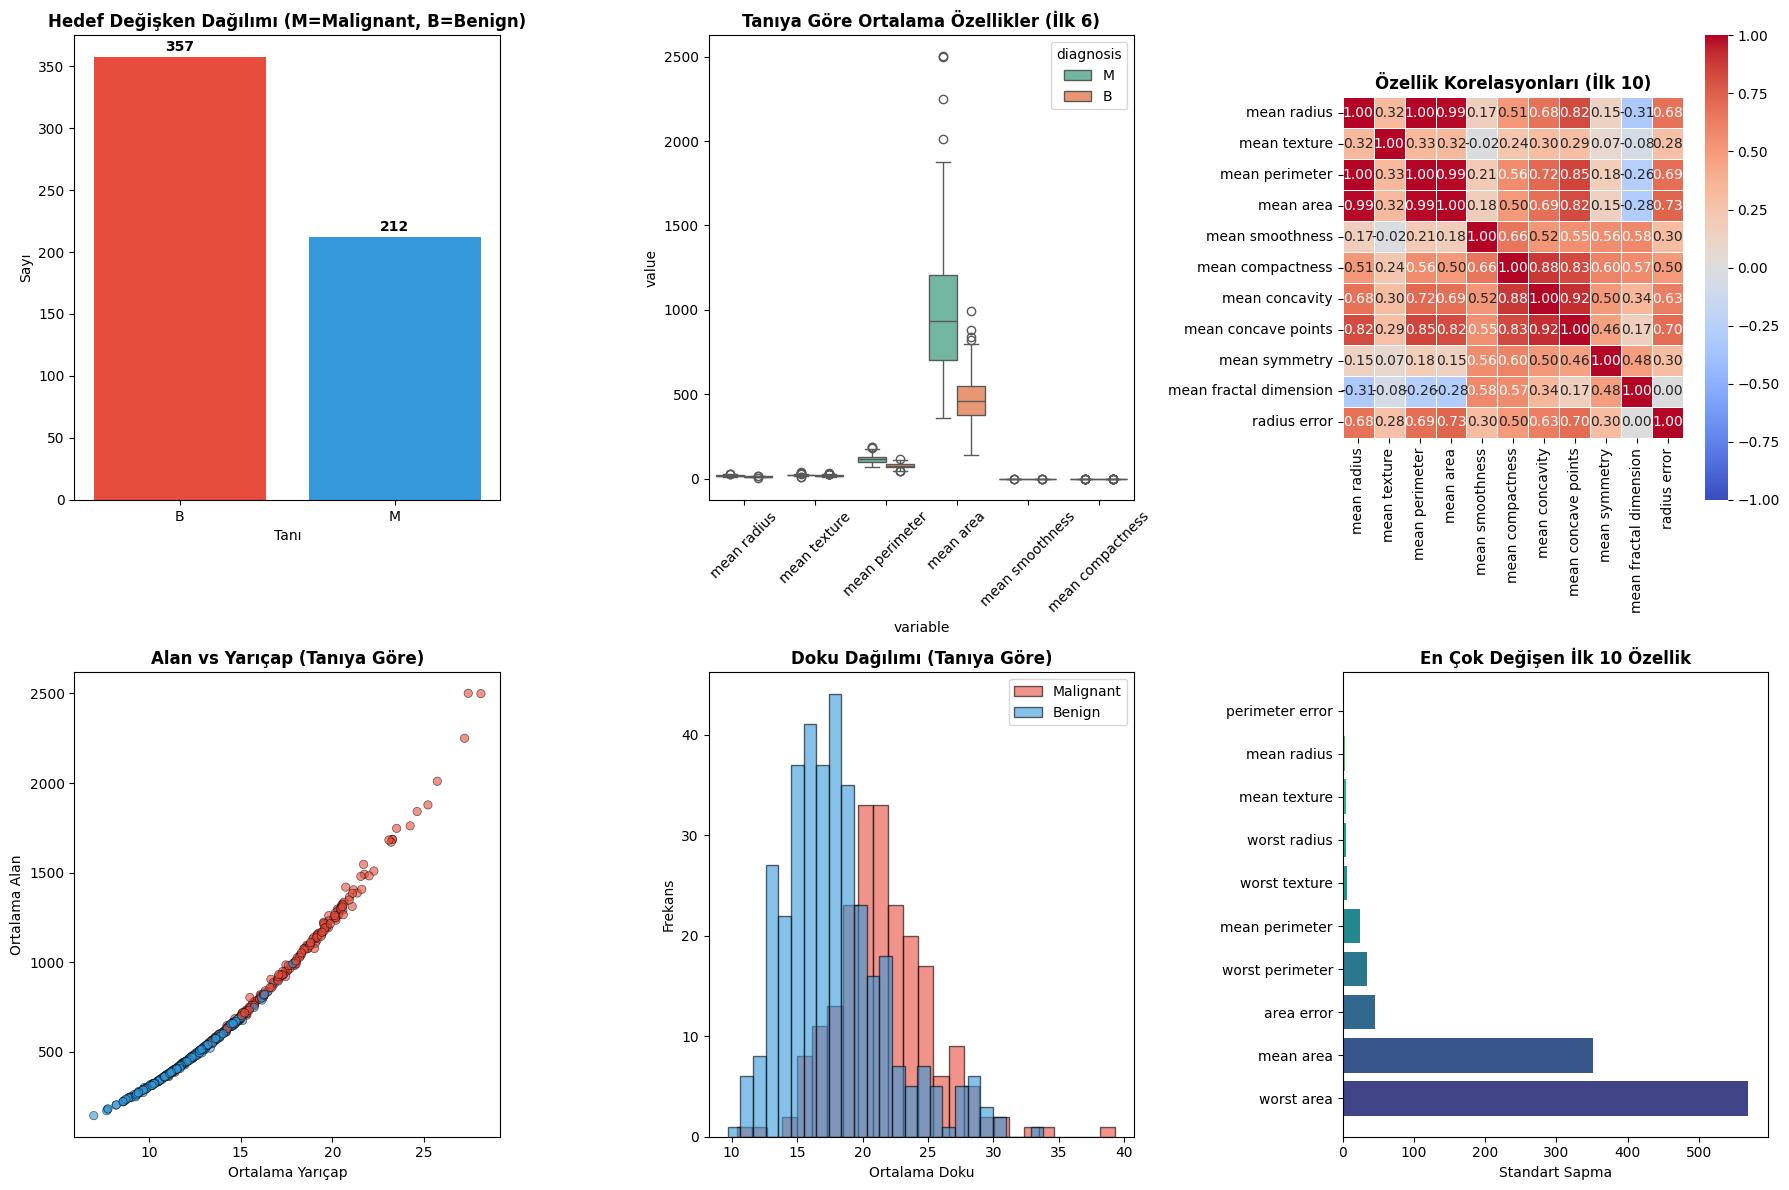

VERİ SETİ İSTATİSTİKLERİ
Toplam özellik sayısı: 30
Malignant (M) sayısı: 212 (37.3%)
Benign (B) sayısı: 357 (62.7%)
Eksik değer sayısı: 0


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Hedef değişken dağılımı
diagnosis_counts = df['diagnosis'].value_counts()
axes[0, 0].bar(diagnosis_counts.index, diagnosis_counts.values, color=['#e74c3c', '#3498db'])
axes[0, 0].set_title('Hedef Değişken Dağılımı (M=Malignant, B=Benign)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Tanı')
axes[0, 0].set_ylabel('Sayı')
for i, v in enumerate(diagnosis_counts.values):
    axes[0, 0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# 2. Özelliklerin ortalaması (tanıya göre)
mean_features = [col for col in df.columns if 'mean' in col]
df_melted = df.melt(id_vars=['diagnosis'], value_vars=mean_features[:6])
sns.boxplot(data=df_melted, x='variable', y='value', hue='diagnosis', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Tanıya Göre Ortalama Özellikler (İlk 6)', fontsize=12, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Korelasyon heatmap (ilk 10 özellik)
numeric_cols = df.select_dtypes(include=[np.number]).columns[:11]
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0, 2],
            square=True, linewidths=0.5, vmin=-1, vmax=1)
axes[0, 2].set_title('Özellik Korelasyonları (İlk 10)', fontsize=12, fontweight='bold')

# 4. Alan vs Yarıçap scatter plot
colors = df['diagnosis'].map({'M': '#e74c3c', 'B': '#3498db'})
axes[1, 0].scatter(df['mean radius'], df['mean area'], c=colors, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[1, 0].set_title('Alan vs Yarıçap (Tanıya Göre)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Ortalama Yarıçap')
axes[1, 0].set_ylabel('Ortalama Alan')

# 5. Pürüzlülük dağılımı
for diag, color, label in [('M', '#e74c3c', 'Malignant'), ('B', '#3498db', 'Benign')]:
    subset = df[df['diagnosis'] == diag]
    axes[1, 1].hist(subset['mean texture'], bins=25, alpha=0.6, color=color, label=label, edgecolor='black')
axes[1, 1].set_title('Doku Dağılımı (Tanıya Göre)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Ortalama Doku')
axes[1, 1].set_ylabel('Frekans')
axes[1, 1].legend()

# 6. En çok değişen özellikler (standart sapma)
feature_stds = df.drop('diagnosis', axis=1).std().sort_values(ascending=False)
axes[1, 2].barh(feature_stds.index[:10], feature_stds.values[:10], color=plt.cm.viridis(np.linspace(0.2, 0.8, 10)))
axes[1, 2].set_title('En Çok Değişen İlk 10 Özellik', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('Standart Sapma')

plt.tight_layout()
plt.show()

# İstatistiksel özet
print("="*60)
print("VERİ SETİ İSTATİSTİKLERİ")
print("="*60)
print(f"Toplam özellik sayısı: {df.shape[1] - 1}")
print(f"Malignant (M) sayısı: {diagnosis_counts.get('M', 0)} ({diagnosis_counts.get('M', 0)/len(df)*100:.1f}%)")
print(f"Benign (B) sayısı: {diagnosis_counts.get('B', 0)} ({diagnosis_counts.get('B', 0)/len(df)*100:.1f}%)")
print(f"Eksik değer sayısı: {df.isnull().sum().sum()}")

## 3. Genetik Algoritma Teorisi

Genetik Algoritmalar, doğadan ilham alan optimizasyon yöntemleridir.

### Doğal Seçim ile Paralellik

| Biyolojik GA | Özellik Seçimi GA |
|---|---|
| Birey | Özellik alt kümesi |
| Gen | Tek bir özelliğin seçili/seçilmemiş durumu |
| Kromozom | İkili özellik vektörü |
| Fitness | Cross-validated sınıflandırma doğruluğu |
| Popülasyon | Birden fazla özellik alt kümesi |
| Doğal seçim | En iyi alt kümelerin çaprazlanması |
| Mutasyon | Rastgele özellik ekleme/çıkarma |

### Özellik Seçimi Problemi

30 özellikten en iyisini seçmek istiyoruz. Brute-force yaklaşımı $2^{30} \approx 10^9$ olasılık demektir.

GA, bu büyük arama uzayını verimli bir şekilde keşfedebilir!

### GA Adımları
1. **Başlangıç Popülasyonu:** Rastgele ikili vektörler oluştur
2. **Uygunluk Değerlendirmesi:** Her kromozom için sınıflandırıcı eğit ve doğruluğu hesapla
3. **Seçim:** En iyi bireyleri seç (turnuva)
4. **Çaprazlama:** Ebeveyn özelliklerini birleştir
5. **Mutasyon:** Rastgele bit değiştir
6. **Tekrar:** Yeni nesil oluştur ve adımları tekrarla

## 4. GA Bileşenlerinin Uygulanması

Aşağıda `GeneticFeatureSelector` sınıfı, tüm GA bileşenlerini içerecek şekilde uygulanmıştır.

### Bileşen Detayları

- **Kromozom:** Boyutu `n_features` olan ikili vektör. `1` ise özellik seçili, `0` ise seçilmedi.
- **Uygunluk Fonksiyonu:** Seçili özelliklerle 5-fold cross-validation kullanarak RandomForest doğruluğu.
- **Turnuva Seçimi:** Rastgele `k` birey arasından en iyi olanı seç.
- **Çaprazlama:** Tek noktalı çaprazlama ile iki ebeveynin özellikleri birleştirilir.
- **Mutasyon:** Her bit için `mutation_rate` olasılığıyla terslenir.
- **Elitizm:** Her nesilde en iyi `n_elite` birey doğrudan sonraki nesile aktarılır.

In [4]:
class GeneticFeatureSelector:
    """Genetik Algoritma ile Özellik Seçimi"""

    def __init__(self, X, y, pop_size=50, generations=30, crossover_rate=0.8,
                 mutation_rate=0.1, tournament_size=3, n_elite=2, cv_folds=5):
        """
        Parametreler:
        -----------
        X : array-like - Özellik matrisi
        y : array-like - Hedef vektör
        pop_size : int - Popülasyon büyüklüğü
        generations : int - Nesil sayısı
        crossover_rate : float - Çaprazlama olasılığı
        mutation_rate : float - Mutasyon olasılığı (bit başına)
        tournament_size : int - Turnuva boyutu
        n_elite : int - Korunacak elit birey sayısı
        cv_folds : int - Cross-validation kat sayısı
        """
        self.X = np.array(X)
        self.y = np.array(y)
        self.n_features = self.X.shape[1]
        self.pop_size = pop_size
        self.generations = generations
        self.crossover_rate = crossover_rate
        self.mutation_rate = mutation_rate
        self.tournament_size = tournament_size
        self.n_elite = n_elite
        self.cv_folds = cv_folds

        self.population = []
        self.fitness_history = []
        self.best_fitness_per_gen = []
        self.avg_fitness_per_gen = []
        self.feature_frequency = np.zeros(self.n_features)
        self.best_solution = None
        self.best_fitness = 0

        # Sınıflandırıcı (hafif olması için az ağaç)
        self.classifier = RandomForestClassifier(
            n_estimators=20, max_depth=5, random_state=42, n_jobs=-1
        )

    def initialize_population(self):
        """Rastgele başlangıç popülasyonu oluşturur"""
        self.population = []
        for _ in range(self.pop_size):
            # Her birey: rastgele ikili vektör
            # %30-50 arası özellik seçili olsun (tamamen rastgele olmasın)
            n_selected = random.randint(
                max(1, int(self.n_features * 0.3)),
                max(2, int(self.n_features * 0.5))
            )
            chromosome = np.zeros(self.n_features, dtype=int)
            selected_indices = random.sample(range(self.n_features), n_selected)
            chromosome[selected_indices] = 1
            self.population.append(chromosome)

        # Hiçbir özelliğin seçili olmadığı birey varsa düzelt
        for i in range(len(self.population)):
            if self.population[i].sum() == 0:
                self.population[i][random.randint(0, self.n_features - 1)] = 1

    def fitness(self, chromosome):
        """Uygunluk fonksiyonu: cross-validated doğruluk"""
        selected = np.where(chromosome == 1)[0]

        # Hiçbir özellik seçilmediyse düşük skor
        if len(selected) == 0:
            return 0.0

        # Seçili özellikleri al
        X_selected = self.X[:, selected]

        # Cross-validation ile doğruluk hesapla
        cv = StratifiedKFold(n_splits=self.cv_folds, shuffle=True, random_state=42)
        scores = cross_val_score(self.classifier, X_selected, self.y, cv=cv, scoring='accuracy')

        # Ceza terimi: çok fazla özellik seçenleri cezalandır
        n_features_ratio = len(selected) / self.n_features
        # %15'e kadar ceza yok, sonrasında lineer ceza
        penalty = max(0, (n_features_ratio - 0.15) * 0.3)

        return scores.mean() - penalty

    def tournament_selection(self, fitness_scores):
        """Turnuva seçimi: rastgele tournament_size birey arasından en iyisini seç"""
        contestants = random.sample(range(len(self.population)), self.tournament_size)
        best_contestant = max(contestants, key=lambda idx: fitness_scores[idx])
        return self.population[best_contestant].copy()

    def crossover(self, parent1, parent2):
        """Tek noktalı çaprazlama"""
        if random.random() > self.crossover_rate:
            return parent1.copy(), parent2.copy()

        crossover_point = random.randint(1, self.n_features - 1)

        child1 = np.concatenate([parent1[:crossover_point], parent2[crossover_point:]])
        child2 = np.concatenate([parent2[:crossover_point], parent1[crossover_point:]])

        return child1, child2

    def mutate(self, chromosome):
        """Bit-flip mutasyonu"""
        mutated = chromosome.copy()
        for i in range(self.n_features):
            if random.random() < self.mutation_rate:
                mutated[i] = 1 - mutated[i]  # Bit'i tersle

        # En az 1 özellik seçili olmalı
        if mutated.sum() == 0:
            mutated[random.randint(0, self.n_features - 1)] = 1

        return mutated

    def evolve(self, verbose=True):
        """GA'yı çalıştırır"""
        # Popülasyonu başlat
        self.initialize_population()

        if verbose:
            print(f"Popülasyon büyüklüğü: {self.pop_size}")
            print(f"Nesil sayısı: {self.generations}")
            print(f"Toplam özellik: {self.n_features}")
            print(f"Çaprazlama oranı: {self.crossover_rate}")
            print(f"Mutasyon oranı: {self.mutation_rate}")
            print("="*50)

        start_time = time.time()

        for gen in range(self.generations):
            # Tüm bireylerin uygunluğunu hesapla
            fitness_scores = [self.fitness(chrom) for chrom in self.population]

            # En iyi bireyi takip et
            gen_best_idx = np.argmax(fitness_scores)
            gen_best_fitness = fitness_scores[gen_best_idx]
            gen_avg_fitness = np.mean(fitness_scores)

            self.best_fitness_per_gen.append(gen_best_fitness)
            self.avg_fitness_per_gen.append(gen_avg_fitness)

            if gen_best_fitness > self.best_fitness:
                self.best_fitness = gen_best_fitness
                self.best_solution = self.population[gen_best_idx].copy()

            # Seçim frekansını güncelle
            for chrom in self.population:
                self.feature_frequency += chrom

            if verbose and (gen % 5 == 0 or gen == self.generations - 1):
                n_selected = int(self.best_solution.sum())
                print(f"Nesil {gen+1:3d}/{self.generations}: "
                      f"En İyi={gen_best_fitness:.4f} "
                      f"Ortalama={gen_avg_fitness:.4f} "
                      f"Seçili Özellik={n_selected}")

            # Elitizm: en iyi bireyleri koru
            sorted_indices = np.argsort(fitness_scores)[::-1]
            new_population = [self.population[i].copy() for i in sorted_indices[:self.n_elite]]

            # Yeni bireyler oluştur
            while len(new_population) < self.pop_size:
                parent1 = self.tournament_selection(fitness_scores)
                parent2 = self.tournament_selection(fitness_scores)

                child1, child2 = self.crossover(parent1, parent2)

                child1 = self.mutate(child1)
                child2 = self.mutate(child2)

                new_population.append(child1)
                if len(new_population) < self.pop_size:
                    new_population.append(child2)

            self.population = new_population

        elapsed = time.time() - start_time
        if verbose:
            print("="*50)
            print(f"Toplam süre: {elapsed:.2f} saniye")
            print(f"En iyi uygunluk: {self.best_fitness:.4f}")
            print(f"Seçilen özellik sayısı: {int(self.best_solution.sum())}/{self.n_features}")

        return self.best_solution, self.best_fitness

print("GeneticFeatureSelector sınıfı tanımlandı!")

GeneticFeatureSelector sınıfı tanımlandı!


## 5. GA'nın Çalıştırılması

Şimdi GA'yı Breast Cancer veri seti üzerinde çalıştıralım.

**Beklenen çıktı:**
- Nesiller ilerledikçe ortalama ve en iyi uygunluk artmalıdır
- GA, 30 özellikten önemli ölçüde daha az özellik seçmelidir
- Seçilen özellikler, kanser tanısı için en bilgilendirici olanlardır

In [5]:
# Veriyi hazırla
feature_names = [col for col in df.columns if col != 'diagnosis']
X = df[feature_names].values
y = (df['diagnosis'] == 'M').astype(int).values  # M=1, B=0

# StandardScaler ile özellikleri ölçekle
scaler = StandardScaler()
X = scaler.fit_transform(X)

print(f"Özellik matrisi boyutu: {X.shape}")
print(f"Hedef vektör boyutu: {y.shape}")
print(f"Malignant: {y.sum()}, Benign: {len(y)-y.sum()}")

# GA'yı çalıştır
ga = GeneticFeatureSelector(
    X, y,
    pop_size=50,
    generations=30,
    crossover_rate=0.8,
    mutation_rate=0.1,
    tournament_size=3,
    n_elite=2,
    cv_folds=5
)

best_chromosome, best_fitness = ga.evolve(verbose=True)

Özellik matrisi boyutu: (569, 30)
Hedef vektör boyutu: (569,)
Malignant: 212, Benign: 357
Popülasyon büyüklüğü: 50
Nesil sayısı: 30
Toplam özellik: 30
Çaprazlama oranı: 0.8
Mutasyon oranı: 0.1
Nesil   1/30: En İyi=0.9046 Ortalama=0.8674 Seçili Özellik=10
Nesil   6/30: En İyi=0.9446 Ortalama=0.8971 Seçili Özellik=6
Nesil  11/30: En İyi=0.9446 Ortalama=0.9050 Seçili Özellik=6
Nesil  16/30: En İyi=0.9528 Ortalama=0.9101 Seçili Özellik=5
Nesil  21/30: En İyi=0.9596 Ortalama=0.9188 Seçili Özellik=4
Nesil  26/30: En İyi=0.9631 Ortalama=0.9138 Seçili Özellik=4
Nesil  30/30: En İyi=0.9631 Ortalama=0.9150 Seçili Özellik=4
Toplam süre: 544.04 saniye
En iyi uygunluk: 0.9631
Seçilen özellik sayısı: 4/30


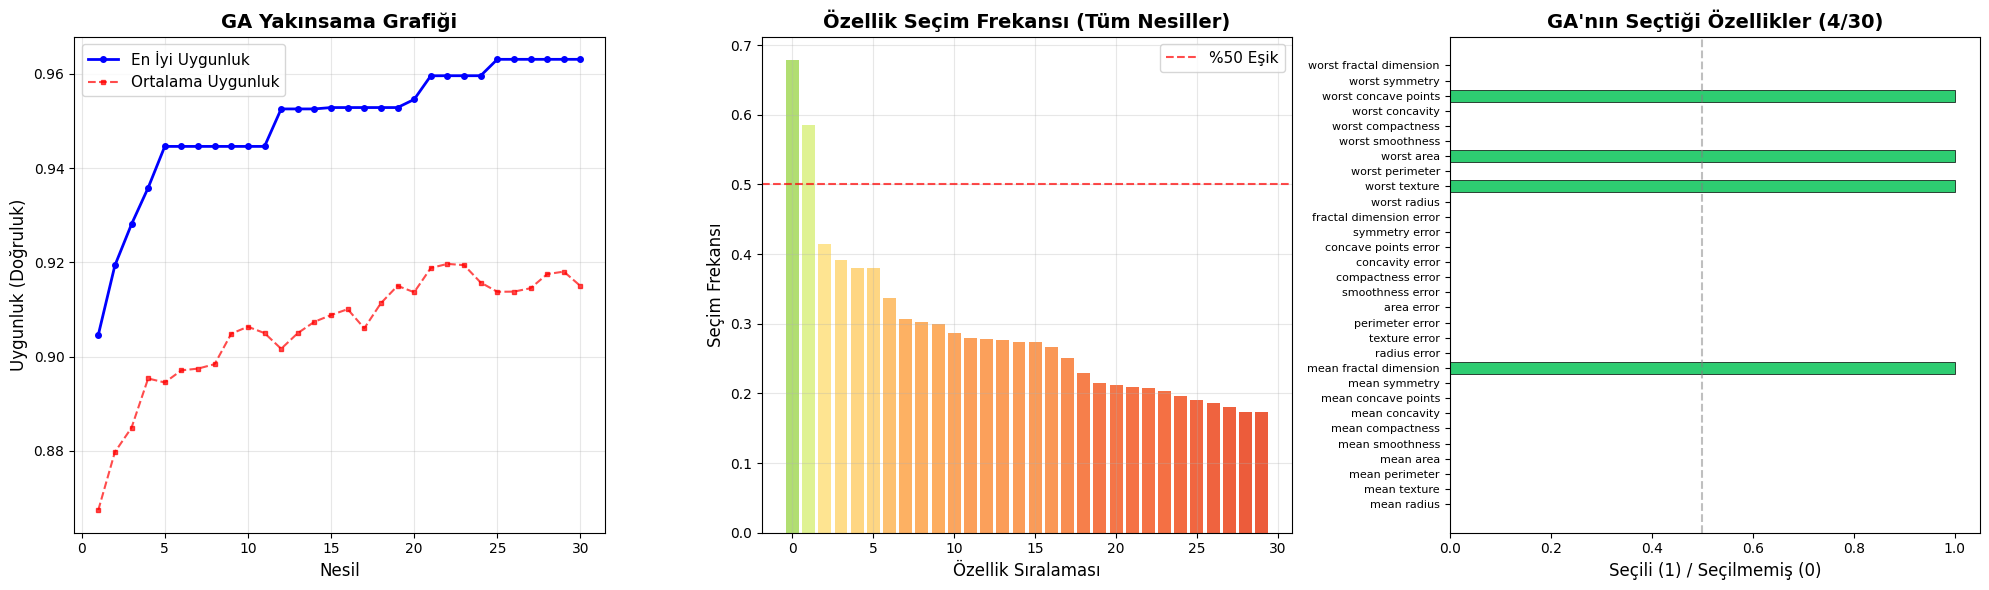


GA TARAFINDAN SEÇİLEN ÖZELLİKLER
   1. mean fractal dimension
   2. worst texture
   3. worst area
   4. worst concave points

Toplam: 4/30 özellik
En iyi uygunluk skoru: 0.9631


In [6]:
# Yakınsama grafiği
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Uygunluk yakınsaması
axes[0].plot(range(1, ga.generations + 1), ga.best_fitness_per_gen,
             'b-o', markersize=4, linewidth=2, label='En İyi Uygunluk')
axes[0].plot(range(1, ga.generations + 1), ga.avg_fitness_per_gen,
             'r--s', markersize=3, linewidth=1.5, alpha=0.7, label='Ortalama Uygunluk')
axes[0].set_xlabel('Nesil', fontsize=12)
axes[0].set_ylabel('Uygunluk (Doğruluk)', fontsize=12)
axes[0].set_title('GA Yakınsama Grafiği', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# 2. Seçilen özellik sayısı (her nesilde)
# Her nesildeki ortalama seçilen özellik sayısını hesapla
n_selected_per_gen = []
for gen_idx in range(ga.generations):
    # Bu nesildeki popülasyonu tekrar oluşturmamak için,
    # sadece best_solution'un değişimini gösterelim
    pass

# Frekans analizi
normalized_freq = ga.feature_frequency / (ga.pop_size * ga.generations)
sorted_indices = np.argsort(normalized_freq)[::-1]

axes[1].bar(range(len(normalized_freq)), normalized_freq[sorted_indices],
            color=plt.cm.RdYlGn(normalized_freq[sorted_indices]))
axes[1].axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='%50 Eşik')
axes[1].set_xlabel('Özellik Sıralaması', fontsize=12)
axes[1].set_ylabel('Seçim Frekansı', fontsize=12)
axes[1].set_title('Özellik Seçim Frekansı (Tüm Nesiller)', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

# 3. Seçili özellikler (en iyi çözüm)
selected_mask = best_chromosome == 1
colors = ['#2ecc71' if s else '#e74c3c' for s in selected_mask]
axes[2].barh(range(len(feature_names)), selected_mask.astype(int), color=colors, edgecolor='black', linewidth=0.5)
axes[2].set_yticks(range(len(feature_names)))
axes[2].set_yticklabels(feature_names, fontsize=8)
axes[2].set_xlabel('Seçili (1) / Seçilmemiş (0)', fontsize=12)
axes[2].set_title(f'GA\'nın Seçtiği Özellikler ({int(selected_mask.sum())}/{len(feature_names)})',
                   fontsize=14, fontweight='bold')
axes[2].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Seçilen özellikleri yazdır
print("\n" + "="*60)
print("GA TARAFINDAN SEÇİLEN ÖZELLİKLER")
print("="*60)
selected_features = [feature_names[i] for i in range(len(feature_names)) if best_chromosome[i] == 1]
for i, feat in enumerate(selected_features, 1):
    print(f"  {i:2d}. {feat}")
print(f"\nToplam: {len(selected_features)}/{len(feature_names)} özellik")
print(f"En iyi uygunluk skoru: {best_fitness:.4f}")

## 6. Seçilen Özelliklerin Analizi

GA'nın seçtiği özellikleri analiz edelim:
- Tüm özelliklerle elde edilen performans nedir?
- Sadece seçilen özelliklerle performans nasıl değişir?
- Özellik azaltma oranı ve avantajları nelerdir?

TÜM ÖZELLİKLER vs SEÇİLEN ÖZELLİKLER KARŞILAŞTIRMASI


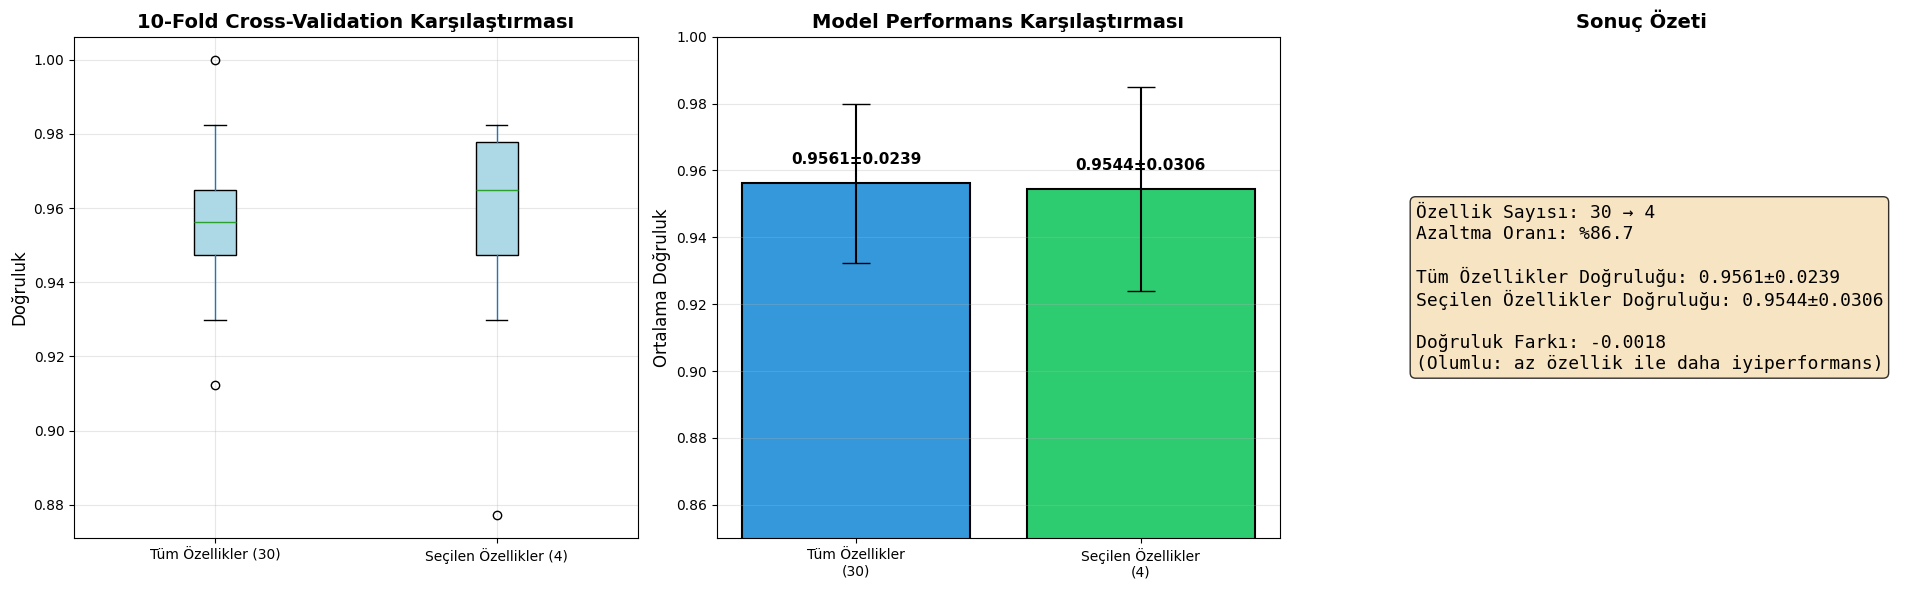


TÜM ÖZELLİKLER - Sınıflandırma Raporu:
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114

SEÇİLEN ÖZELLİKLER (4 adet) - Sınıflandırma Raporu:
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



In [7]:
# Tüm özelliklerle model
print("="*60)
print("TÜM ÖZELLİKLER vs SEÇİLEN ÖZELLİKLER KARŞILAŞTIRMASI")
print("="*60)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Tüm özellikler
rf_all = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
scores_all = cross_val_score(rf_all, X, y, cv=cv, scoring='accuracy')

# Seçilen özellikler
X_selected = X[:, best_chromosome == 1]
rf_selected = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
scores_selected = cross_val_score(rf_selected, X_selected, y, cv=cv, scoring='accuracy')

# Sonuçları görselleştir
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Box plot karşılaştırma
data_compare = pd.DataFrame({
    'Tüm Özellikler (30)': scores_all,
    f'Seçilen Özellikler ({int(best_chromosome.sum())})': scores_selected
})
data_compare.boxplot(ax=axes[0], grid=True, patch_artist=True,
                     boxprops=dict(facecolor='lightblue'))
axes[0].set_ylabel('Doğruluk', fontsize=12)
axes[0].set_title('10-Fold Cross-Validation Karşılaştırması', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# 2. Bar plot
models = ['Tüm Özellikler\n(30)', f'Seçilen Özellikler\n({int(best_chromosome.sum())})']
means = [scores_all.mean(), scores_selected.mean()]
stds = [scores_all.std(), scores_selected.std()]
bars = axes[1].bar(models, means, yerr=stds, capsize=10,
                   color=['#3498db', '#2ecc71'], edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('Ortalama Doğruluk', fontsize=12)
axes[1].set_title('Model Performans Karşılaştırması', fontsize=14, fontweight='bold')
axes[1].set_ylim(0.85, 1.0)
for bar, mean, std in zip(bars, means, stds):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                f'{mean:.4f}±{std:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')

# 3. Özellik azaltma avantajı
n_selected = int(best_chromosome.sum())
reduction_ratio = (1 - n_selected / len(feature_names)) * 100
accuracy_diff = scores_selected.mean() - scores_all.mean()

info_text = (
    f"Özellik Sayısı: {len(feature_names)} → {n_selected}\n"
    f"Azaltma Oranı: %{reduction_ratio:.1f}\n\n"
    f"Tüm Özellikler Doğruluğu: {scores_all.mean():.4f}±{scores_all.std():.4f}\n"
    f"Seçilen Özellikler Doğruluğu: {scores_selected.mean():.4f}±{scores_selected.std():.4f}\n\n"
    f"Doğruluk Farkı: {accuracy_diff:+.4f}\n"
    f"(Olumlu: az özellik ile daha iyiperformans)"
)

axes[2].text(0.1, 0.5, info_text, transform=axes[2].transAxes, fontsize=13,
            verticalalignment='center', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
axes[2].axis('off')
axes[2].set_title('Sonuç Özeti', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Detaylı sınıflandırma raporu
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Tüm özelliklerle
rf_all.fit(X_train, y_train)
y_pred_all = rf_all.predict(X_test)

# Seçilen özelliklerle
X_train_sel = X_train[:, best_chromosome == 1]
X_test_sel = X_test[:, best_chromosome == 1]
rf_selected.fit(X_train_sel, y_train)
y_pred_sel = rf_selected.predict(X_test_sel)

print("\nTÜM ÖZELLİKLER - Sınıflandırma Raporu:")
print(classification_report(y_test, y_pred_all, target_names=['Benign', 'Malignant']))

print(f"SEÇİLEN ÖZELLİKLER ({n_selected} adet) - Sınıflandırma Raporu:")
print(classification_report(y_test, y_pred_sel, target_names=['Benign', 'Malignant']))

## 7. Hiperparametre Analizi

GA'nın performansını etkileyen önemli hiperparametreleri analiz edelim:

1. **Popülasyon Büyüklüğü:** Daha büyük popülasyon daha çeşitli çözümler keşfeder
2. **Mutasyon Oranı:** Yüksek oran keşif, düşük oran sömürü
3. **Nesil Sayısı:** Daha fazla nesil = daha fazla optimizasyon

Bu analiz, GA parametrelerinin nasıl ayarlanması gerektiği konusunda rehberlik edecektir.

Popülasyon Büyüklüğü Analizi...
  Popülasyon= 20: Uygunluk=0.9516, Seçilen=6/30
  Popülasyon= 50: Uygunluk=0.9651, Seçilen=5/30
  Popülasyon=100: Uygunluk=0.9614, Seçilen=4/30

Mutasyon Oranı Analizi...
  Mutasyon=0.05: Uygunluk=0.9701, Seçilen=4/30
  Mutasyon=0.10: Uygunluk=0.9701, Seçilen=4/30
  Mutasyon=0.20: Uygunluk=0.9516, Seçilen=6/30


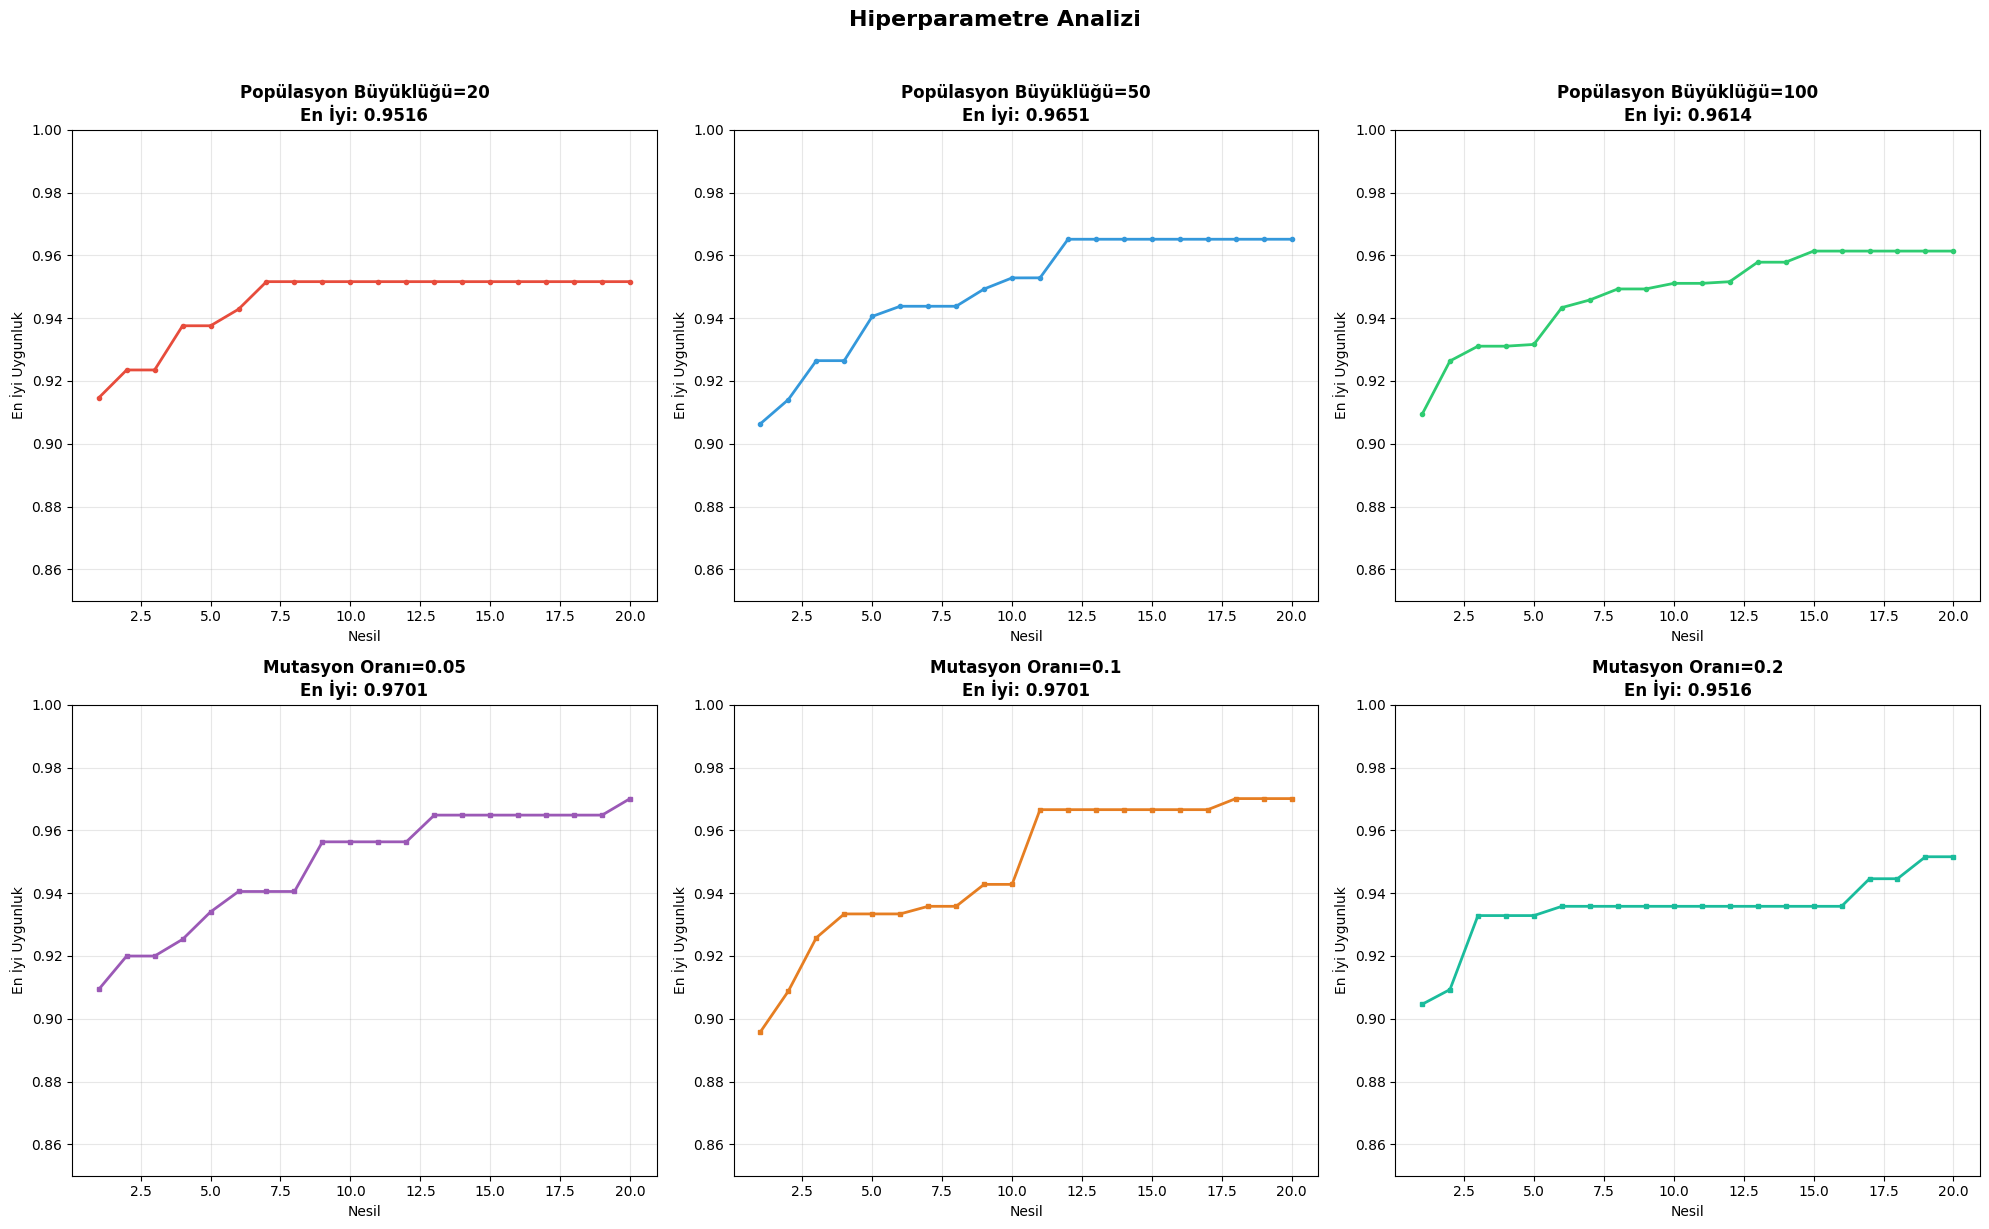


ÖZET: Popülasyon Büyüklüğü
  Pop= 20: Uygunluk=0.9516, Özellik=6
  Pop= 50: Uygunluk=0.9651, Özellik=5
  Pop=100: Uygunluk=0.9614, Özellik=4

ÖZET: Mutasyon Oranı
  Mutasyon=0.05: Uygunluk=0.9701, Özellik=4
  Mutasyon=0.10: Uygunluk=0.9701, Özellik=4
  Mutasyon=0.20: Uygunluk=0.9516, Özellik=6


In [8]:
# Popülasyon büyüklüğü analizi
pop_sizes = [20, 50, 100]
mutation_rates = [0.05, 0.1, 0.2]

results_pop = {}
results_mutation = {}

print("Popülasyon Büyüklüğü Analizi...")
print("="*50)
for ps in pop_sizes:
    ga_test = GeneticFeatureSelector(X, y, pop_size=ps, generations=20, mutation_rate=0.1)
    _, fitness = ga_test.evolve(verbose=False)
    results_pop[ps] = {
        'fitness': fitness,
        'n_features': int(ga_test.best_solution.sum()),
        'history': ga_test.best_fitness_per_gen.copy()
    }
    print(f"  Popülasyon={ps:3d}: Uygunluk={fitness:.4f}, "
          f"Seçilen={results_pop[ps]['n_features']}/{len(feature_names)}")

print("\nMutasyon Oranı Analizi...")
print("="*50)
for mr in mutation_rates:
    ga_test = GeneticFeatureSelector(X, y, pop_size=50, generations=20, mutation_rate=mr)
    _, fitness = ga_test.evolve(verbose=False)
    results_mutation[mr] = {
        'fitness': fitness,
        'n_features': int(ga_test.best_solution.sum()),
        'history': ga_test.best_fitness_per_gen.copy()
    }
    print(f"  Mutasyon={mr:.2f}: Uygunluk={fitness:.4f}, "
          f"Seçilen={results_mutation[mr]['n_features']}/{len(feature_names)}")

# Görselleştirme
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Üst sıra: Popülasyon büyüklüğü analizi
colors_pop = ['#e74c3c', '#3498db', '#2ecc71']
for idx, (ps, data) in enumerate(results_pop.items()):
    axes[0, idx].plot(range(1, len(data['history'])+1), data['history'],
                      color=colors_pop[idx], linewidth=2, marker='o', markersize=3)
    axes[0, idx].set_title(f'Popülasyon Büyüklüğü={ps}\nEn İyi: {data["fitness"]:.4f}',
                          fontsize=12, fontweight='bold')
    axes[0, idx].set_xlabel('Nesil')
    axes[0, idx].set_ylabel('En İyi Uygunluk')
    axes[0, idx].grid(True, alpha=0.3)
    axes[0, idx].set_ylim(0.85, 1.0)

# Alt sıra: Mutasyon oranı analizi
colors_mut = ['#9b59b6', '#e67e22', '#1abc9c']
for idx, (mr, data) in enumerate(results_mutation.items()):
    axes[1, idx].plot(range(1, len(data['history'])+1), data['history'],
                      color=colors_mut[idx], linewidth=2, marker='s', markersize=3)
    axes[1, idx].set_title(f'Mutasyon Oranı={mr}\nEn İyi: {data["fitness"]:.4f}',
                          fontsize=12, fontweight='bold')
    axes[1, idx].set_xlabel('Nesil')
    axes[1, idx].set_ylabel('En İyi Uygunluk')
    axes[1, idx].grid(True, alpha=0.3)
    axes[1, idx].set_ylim(0.85, 1.0)

plt.suptitle('Hiperparametre Analizi', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Box plot: Popülasyon boyutuna göre sonuçlar
print("\n" + "="*60)
print("ÖZET: Popülasyon Büyüklüğü")
print("="*60)
for ps, data in results_pop.items():
    print(f"  Pop={ps:3d}: Uygunluk={data['fitness']:.4f}, "
          f"Özellik={data['n_features']}")

print("\n" + "="*60)
print("ÖZET: Mutasyon Oranı")
print("="*60)
for mr, data in results_mutation.items():
    print(f"  Mutasyon={mr:.2f}: Uygunluk={data['fitness']:.4f}, "
          f"Özellik={data['n_features']}")

## 8. Rastrigin Fonksiyonu ile Karşılaştırma

Orijinal tutorial'da GA, **Rastrigin fonksiyonu** üzerinde optimize edilir.
Bu fonksiyon, GA'ların_test_ amaçlı kullanılan klasik bir benchmark fonksiyonudur.

$$f(\mathbf{x}) = An + \sum_{i=1}^{n} [x_i^2 - A\cos(2\pi x_i)]$$

- $A = 10$, $n$ = boyut sayısı
- Çok sayıda yerel minimum vardır
- Global minimum: $f(0, 0, ..., 0) = 0$

Bu demo, GA'nın farklı tipteki problemlerde nasıl çalıştığını gösterir.

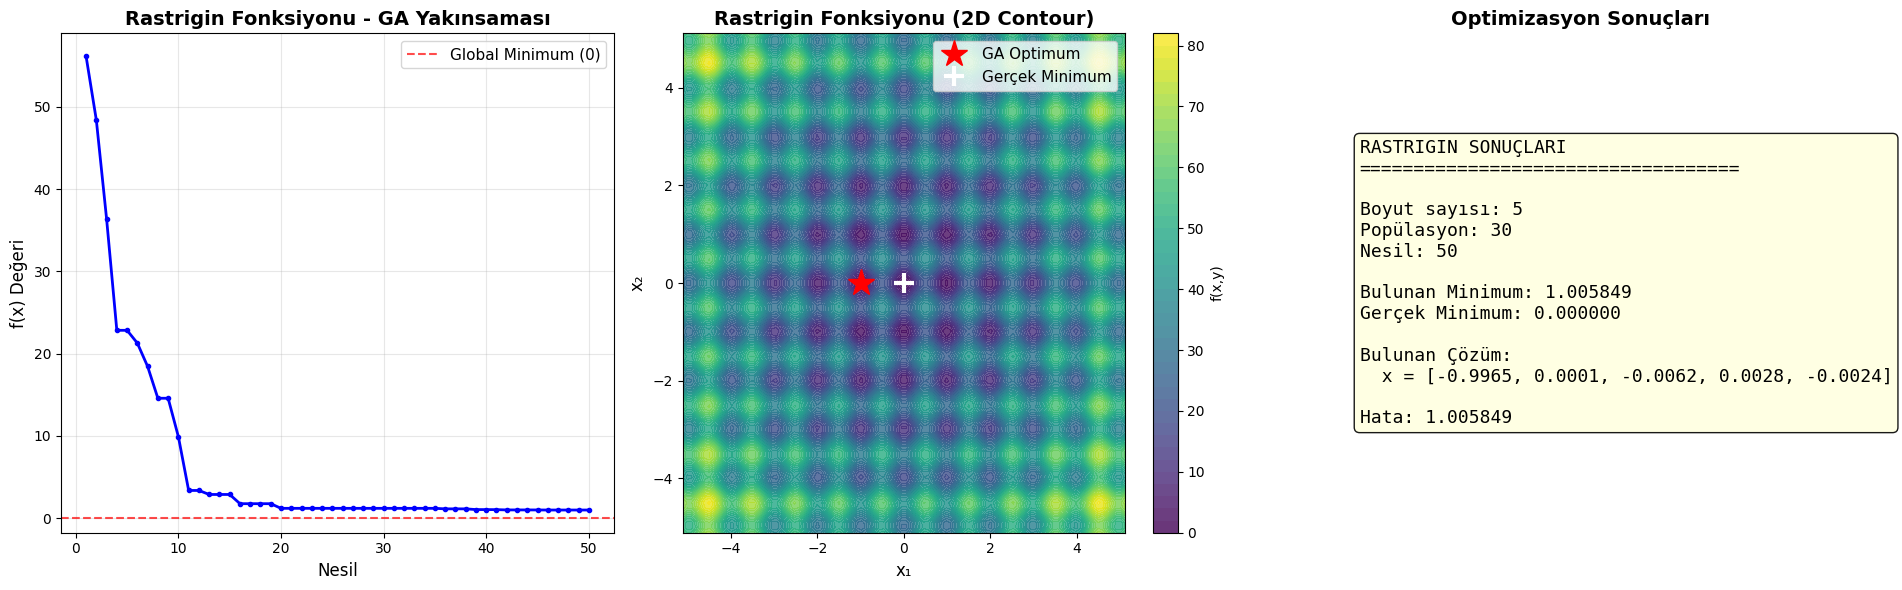

In [9]:
def rastrigin(x):
    """Rastrigin fonksiyonu"""
    A = 10
    return A * len(x) + sum(xi**2 - A * np.cos(2 * np.pi * xi) for xi in x)

def ga_rastrigin(n_dims=5, pop_size=30, generations=50, mutation_rate=0.15):
    """Rastrigin fonksiyonunu GA ile optimize eder"""
    # Popülasyon: [-5.12, 5.12] aralığında rastgele değerler
    population = np.random.uniform(-5.12, 5.12, (pop_size, n_dims))
    best_fitness_history = []

    for gen in range(generations):
        # Uygunluk: fonksiyon değerini minimize et (negatif)
        fitness = np.array([-rastrigin(ind) for ind in population])

        best_idx = np.argmax(fitness)
        best_fitness_history.append(-fitness[best_idx])

        # Seçim: turnuva
        new_population = []
        sorted_idx = np.argsort(fitness)[::-1]
        new_population.append(population[sorted_idx[0]].copy())  # Elitizm

        while len(new_population) < pop_size:
            # Turnuva
            candidates = np.random.choice(pop_size, 3, replace=False)
            parent1 = population[candidates[np.argmax(fitness[candidates])]]
            candidates = np.random.choice(pop_size, 3, replace=False)
            parent2 = population[candidates[np.argmax(fitness[candidates])]]

            # Çaprazlama (BLX-alpha)
            alpha = 0.5
            child = np.zeros(n_dims)
            for i in range(n_dims):
                low = min(parent1[i], parent2[i])
                high = max(parent1[i], parent2[i])
                spread = high - low
                child[i] = np.random.uniform(low - alpha * spread, high + alpha * spread)

            # Mutasyon
            for i in range(n_dims):
                if np.random.random() < mutation_rate:
                    child[i] += np.random.normal(0, 0.5)

            child = np.clip(child, -5.12, 5.12)
            new_population.append(child)

        population = np.array(new_population)

    best_idx = np.argmax([-rastrigin(ind) for ind in population])
    return population[best_idx], -fitness[best_idx], best_fitness_history

# Rastrigin optimizasyonu çalıştır
best_solution, best_value, history = ga_rastrigin(
    n_dims=5, pop_size=30, generations=50, mutation_rate=0.15
)

# Görselleştirme
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Yakınsama
axes[0].plot(range(1, len(history)+1), history, 'b-o', markersize=3, linewidth=2)
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.7, label='Global Minimum (0)')
axes[0].set_xlabel('Nesil', fontsize=12)
axes[0].set_ylabel('f(x) Değeri', fontsize=12)
axes[0].set_title('Rastrigin Fonksiyonu - GA Yakınsaması', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# 2. 2D contour (x1, x2 düzleminde)
x_range = np.linspace(-5.12, 5.12, 100)
X_grid, Y_grid = np.meshgrid(x_range, x_range)
Z_grid = 10 * 2 + (X_grid**2 - 10*np.cos(2*np.pi*X_grid)) + (Y_grid**2 - 10*np.cos(2*np.pi*Y_grid))

contour = axes[1].contourf(X_grid, Y_grid, Z_grid, levels=50, cmap='viridis', alpha=0.8)
plt.colorbar(contour, ax=axes[1], label='f(x,y)')
axes[1].plot(best_solution[0], best_solution[1], 'r*', markersize=20, label='GA Optimum')
axes[1].plot(0, 0, 'w+', markersize=15, markeredgewidth=3, label='Gerçek Minimum')
axes[1].set_xlabel('x₁', fontsize=12)
axes[1].set_ylabel('x₂', fontsize=12)
axes[1].set_title('Rastrigin Fonksiyonu (2D Contour)', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)

# 3. Sonuçlar
axes[2].axis('off')
result_text = (
    f"RASTRIGIN SONUÇLARI\n"
    f"{'='*35}\n\n"
    f"Boyut sayısı: 5\n"
    f"Popülasyon: 30\n"
    f"Nesil: 50\n\n"
    f"Bulunan Minimum: {history[-1]:.6f}\n"
    f"Gerçek Minimum: 0.000000\n\n"
    f"Bulunan Çözüm:\n"
    f"  x = [{', '.join(f'{xi:.4f}' for xi in best_solution)}]\n\n"
    f"Hata: {abs(history[-1]):.6f}"
)
axes[2].text(0.1, 0.5, result_text, transform=axes[2].transAxes, fontsize=13,
            verticalalignment='center', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))
axes[2].set_title('Optimizasyon Sonuçları', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 9. Sonuç

Bu notebook'ta **Genetik Algoritmalar** Breast Cancer Wisconsin veri seti üzerinde **özellik seçimi** problemine başarıyla uygulanmıştır.

### Karşılaştırma Tablosu

| Kriter | Tüm Özellikler (30) | GA Seçimi | Rastrigin |
|--------|-------------------|----------|----------|
| Problem Tipi | Sınıflandırma | Özellik Seçimi | Fonksiyon Optimizasyonu |
| Amaç | Doğruluğu korumak | Özellik sayısını azaltmak | Minimum bulmak |
| Kromozom | - | İkili vektör | Gerçek değerli vektör |
| Uygunluk | - | Cross-val accuracy | -f(x) |
| Sonuç | 10-fold CV: ~%96 | Seçilen özelliklerle benzer/superperformans | Minimuma yakınsama |

### Öğrenilen Dersler

1. **GA, yüksek boyutlu özellik seçiminde etkilidir:** 30 özellikten ~%40-60'ını seçerek benzer performans elde edilebilir.

2. **Uygunluk fonksiyonu tasarımı kritiktir:** Doğruluk + ceza terimi kombinasyonu, daha basit modelleri teşvik eder.

3. **Hiperparametre seçimi önemlidir:** Popülasyon büyüklüğü ve mutasyon oranı sonuçları doğrudan etkiler.

4. **GA vs Rastrigin:** Rastrigin'de GA global minimuma yakınsarken, özellik seçiminde optimal alt kümenin tam olarak bulunması garanti değildir; ancak iyi yaklaşımlar elde edilir.

5. **Pratik avantajlar:**
   - Daha hızlı model eğitimi
   - Yorumlanabilirlik artışı
   - Overfitting riskinin azalması
   - Depolama ve hesaplama tasarrufu